# Exploratory Data Analysis: GAIC 2026

**Research Focus:** Investigating data characteristics relevant to shortcut learning and cross-dataset generalization in argument mining.

**Key Questions:**
1. What is the class distribution across datasets? (Imbalance can lead to shortcuts)
2. Are there lexical patterns that discriminate classes within but not across datasets? (Shortcut indicators)
3. How similar/different are datasets in terms of vocabulary? (Transfer potential)
4. What sentence-level features vary across datasets? (Domain characteristics)

In [1]:
import sys
sys.path.insert(0, '..')

from config.paths import PROJECT_ROOT, DATA_DIR, GAIC_DATA_DIR
import json
import pandas as pd
import numpy as np
from collections import Counter, defaultdict
from pathlib import Path
import re

print(f"Project root: {PROJECT_ROOT}")
print(f"GAIC data dir: {GAIC_DATA_DIR}")

Project root: /Users/hanneswidera/Uni/Master/thesis/GAIC_thesis/experiments/..
GAIC data dir: /Users/hanneswidera/Uni/Master/thesis/GAIC_thesis/experiments/../data/GAIC-2026/data


## 1. Data Loading

In [2]:
def load_jsonl(path: Path) -> list[dict]:
    """Load JSONL file into list of dicts."""
    with open(path, 'r') as f:
        return [json.loads(line) for line in f]

# Load train and dev data
train_data = load_jsonl(GAIC_DATA_DIR / 'train.jsonl')
train_labels = load_jsonl(GAIC_DATA_DIR / 'train_labels.jsonl')
dev_data = load_jsonl(GAIC_DATA_DIR / 'dev.jsonl')
dev_labels = load_jsonl(GAIC_DATA_DIR / 'dev_labels.jsonl')

print(f"Train samples: {len(train_data)}")
print(f"Dev samples: {len(dev_data)}")

Train samples: 10200
Dev samples: 3400


In [3]:
def merge_data_labels(data: list[dict], labels: list[dict]) -> pd.DataFrame:
    """Merge data with labels and extract dataset name from ID."""
    label_map = {item['id']: item['label'] for item in labels}
    
    for item in data:
        item['label'] = label_map[item['id']]
        # Extract dataset name from ID (e.g., 'ABSTRCT-train-1' -> 'ABSTRCT')
        item['dataset'] = item['id'].rsplit('-', 2)[0]
    
    return pd.DataFrame(data)

train_df = merge_data_labels(train_data, train_labels)
dev_df = merge_data_labels(dev_data, dev_labels)

# Combine for full analysis
train_df['split'] = 'train'
dev_df['split'] = 'dev'
df = pd.concat([train_df, dev_df], ignore_index=True)

print(f"Total samples: {len(df)}")
print(f"\nColumns: {df.columns.tolist()}")
df.head()

Total samples: 13600

Columns: ['id', 'paper', 'document', 'guidelines', 'sentence', 'label', 'dataset', 'split']


,id,paper,document,guidelines,sentence,label,dataset,split
0,ABSTRCT-train-1,./ABSTRCT/paper/ABSTRCT.pdf,./ABSTRCT/data/ABSTRCT-1.txt,./ABSTRCT/guidelines/ABSTRCT-Guidelines.pdf,Both treatments were safe and well tolerated.,Argument,ABSTRCT,train
1,ABSTRCT-train-2,./ABSTRCT/paper/ABSTRCT.pdf,./ABSTRCT/data/ABSTRCT-3.txt,./ABSTRCT/guidelines/ABSTRCT-Guidelines.pdf,The TAX 326 study shows that docetaxel-platinu...,Argument,ABSTRCT,train
2,ABSTRCT-train-3,./ABSTRCT/paper/ABSTRCT.pdf,./ABSTRCT/data/ABSTRCT-4.txt,./ABSTRCT/guidelines/ABSTRCT-Guidelines.pdf,Docetaxel has shown activity in elderly patien...,Argument,ABSTRCT,train
3,ABSTRCT-train-4,./ABSTRCT/paper/ABSTRCT.pdf,./ABSTRCT/data/ABSTRCT-6.txt,./ABSTRCT/guidelines/ABSTRCT-Guidelines.pdf,Targeted therapies may improve chemotherapy ef...,Argument,ABSTRCT,train
4,ABSTRCT-train-5,./ABSTRCT/paper/ABSTRCT.pdf,./ABSTRCT/data/ABSTRCT-7.txt,./ABSTRCT/guidelines/ABSTRCT-Guidelines.pdf,The incidence of hepatotoxicity during IPT and...,Argument,ABSTRCT,train


## 2. Dataset Overview

Understanding the distribution across datasets is critical - imbalanced representation could lead models to learn dataset-specific patterns.

In [4]:
# Dataset distribution
dataset_counts = df.groupby(['dataset', 'split']).size().unstack(fill_value=0)
dataset_counts['total'] = dataset_counts.sum(axis=1)
dataset_counts = dataset_counts.sort_values('total', ascending=False)

print("Sample distribution per dataset:")
print(dataset_counts)
print(f"\nNumber of datasets: {df['dataset'].nunique()}")

Sample distribution per dataset:
split       dev  train  total
dataset                      
ABSTRCT     340   1020   1360
ACQUA       340   1020   1360
AEC         340   1020   1360
AFS         340   1020   1360
ARGUMINSCI  340   1020   1360
FINARG      340   1020   1360
IAM         340   1020   1360
PE          340   1020   1360
SCIARK      340   1020   1360
USELEC      340   1020   1360

Number of datasets: 10


In [5]:
# Class balance per dataset - CRITICAL for shortcut analysis
class_balance = df.groupby(['dataset', 'label']).size().unstack(fill_value=0)
class_balance['total'] = class_balance.sum(axis=1)
class_balance['arg_ratio'] = class_balance['Argument'] / class_balance['total']
class_balance = class_balance.sort_values('arg_ratio', ascending=False)

print("Class balance per dataset (sorted by Argument ratio):")
print(class_balance.round(3))
print(f"\nOverall Argument ratio: {(df['label'] == 'Argument').mean():.3f}")

Class balance per dataset (sorted by Argument ratio):
label       Argument  No-Argument  total  arg_ratio
dataset                                            
ABSTRCT          680          680   1360        0.5
ACQUA            680          680   1360        0.5
AEC              680          680   1360        0.5
AFS              680          680   1360        0.5
ARGUMINSCI       680          680   1360        0.5
FINARG           680          680   1360        0.5
IAM              680          680   1360        0.5
PE               680          680   1360        0.5
SCIARK           680          680   1360        0.5
USELEC           680          680   1360        0.5

Overall Argument ratio: 0.500


## 3. Sentence-Level Features

Examining basic textual characteristics that may vary across datasets and correlate with labels.

In [7]:
# Add sentence-level features
df['char_len'] = df['sentence'].str.len()
df['word_count'] = df['sentence'].str.split().str.len()
df['avg_word_len'] = df['char_len'] / df['word_count']

# Sentence length stats per dataset
length_stats = df.groupby('dataset')['word_count'].agg(['mean', 'std', 'min', 'max'])
length_stats = length_stats.round(2)
print("Word count statistics per dataset:")
print(length_stats)

Word count statistics per dataset:
             mean    std  min  max
dataset                           
ABSTRCT     20.85  10.13    1   76
ACQUA       20.02  11.98    2   81
AEC         18.32  11.77    3  162
AFS         22.94   8.25    1   40
ARGUMINSCI  18.82  11.27    1   81
FINARG      20.93  13.25    2   85
IAM         23.49  12.83    1  101
PE          19.22   8.36    3   50
SCIARK      23.97  10.41    1   74
USELEC      16.38  12.12    1   80


In [8]:
# Sentence length by class - potential shortcut if lengths differ systematically
length_by_class = df.groupby(['dataset', 'label'])['word_count'].mean().unstack()
length_by_class['diff'] = length_by_class['Argument'] - length_by_class['No-Argument']
length_by_class = length_by_class.round(2)

print("Mean word count by class (positive diff = Arguments are longer):")
print(length_by_class.sort_values('diff', ascending=False))

Mean word count by class (positive diff = Arguments are longer):
label       Argument  No-Argument  diff
dataset                                
ARGUMINSCI     22.39        15.25  7.14
FINARG         23.00        18.87  4.12
USELEC         18.18        14.58  3.60
AFS            24.09        21.79  2.31
PE             20.20        18.25  1.95
SCIARK         24.94        23.01  1.93
IAM            24.41        22.56  1.85
AEC            18.89        17.76  1.13
ACQUA          19.68        20.36 -0.68
ABSTRCT        20.23        21.46 -1.23


## 4. Lexical Analysis: Shortcut Indicators

**Key hypothesis from thesis:** Models learn lexical shortcuts (discourse markers, topic words) that work within datasets but fail across datasets.

We analyze:
1. Discourse markers frequency (because, therefore, however...)
2. Most discriminative words for each class
3. Dataset-specific vocabulary

In [9]:
# Define discourse markers - common shortcut candidates from literature
DISCOURSE_MARKERS = [
    # Causal
    'because', 'therefore', 'thus', 'hence', 'consequently', 'since', 'so',
    # Contrastive
    'however', 'but', 'although', 'nevertheless', 'whereas', 'while', 'yet',
    # Additive
    'moreover', 'furthermore', 'additionally', 'also', 'besides',
    # Conclusion
    'conclude', 'conclusion', 'summary', 'finally', 'overall',
    # Evidence
    'shows', 'suggests', 'indicates', 'demonstrates', 'proves', 'evidence',
    # Opinion/Stance
    'believe', 'think', 'argue', 'claim', 'opinion', 'view'
]

def count_markers(text: str, markers: list[str]) -> dict:
    """Count occurrences of discourse markers in text."""
    text_lower = text.lower()
    words = set(re.findall(r'\b\w+\b', text_lower))
    return {marker: 1 if marker in words else 0 for marker in markers}

# Count discourse markers
marker_counts = df['sentence'].apply(lambda x: count_markers(x, DISCOURSE_MARKERS))
marker_df = pd.DataFrame(marker_counts.tolist())
df_with_markers = pd.concat([df, marker_df], axis=1)

In [10]:
# Discourse marker frequency by class (overall)
marker_by_class = df_with_markers.groupby('label')[DISCOURSE_MARKERS].mean()
marker_by_class = marker_by_class.T
marker_by_class['diff'] = marker_by_class['Argument'] - marker_by_class['No-Argument']
marker_by_class = marker_by_class.sort_values('diff', ascending=False)

print("Discourse marker frequency by class (higher diff = more associated with Argument):")
print(marker_by_class.round(4))

Discourse marker frequency by class (higher diff = more associated with Argument):
label         Argument  No-Argument    diff
so              0.0926       0.0462  0.0465
but             0.1126       0.0666  0.0460
think           0.0560       0.0304  0.0256
conclusion      0.0206       0.0007  0.0199
because         0.0410       0.0244  0.0166
believe         0.0243       0.0084  0.0159
therefore       0.0163       0.0054  0.0109
also            0.0435       0.0343  0.0093
thus            0.0109       0.0037  0.0072
overall         0.0140       0.0069  0.0071
although        0.0131       0.0060  0.0071
conclude        0.0056       0.0003  0.0053
view            0.0084       0.0031  0.0053
evidence        0.0118       0.0069  0.0049
however         0.0174       0.0125  0.0049
shows           0.0072       0.0034  0.0038
suggests        0.0051       0.0015  0.0037
while           0.0172       0.0141  0.0031
argue           0.0050       0.0022  0.0028
demonstrates    0.0019       0.0001  

In [11]:
# Discourse marker association per dataset - are shortcuts consistent across datasets?
def compute_marker_class_association(data: pd.DataFrame, marker: str) -> float:
    """Compute correlation between marker presence and Argument label."""
    return data[marker].corr(data['label'].map({'Argument': 1, 'No-Argument': 0}))

# Top markers to analyze
top_markers = ['because', 'therefore', 'however', 'shows', 'suggests', 'argue']

marker_dataset_corr = {}
for dataset in df_with_markers['dataset'].unique():
    subset = df_with_markers[df_with_markers['dataset'] == dataset]
    marker_dataset_corr[dataset] = {
        marker: compute_marker_class_association(subset, marker) 
        for marker in top_markers
    }

marker_corr_df = pd.DataFrame(marker_dataset_corr).T
print("Marker-Argument correlation per dataset (inconsistency = shortcut risk):")
print(marker_corr_df.round(3))
print(f"\nStd across datasets (high = inconsistent, unreliable shortcut):")
print(marker_corr_df.std().round(3))

Marker-Argument correlation per dataset (inconsistency = shortcut risk):
            because  therefore  however  shows  suggests  argue
ABSTRCT      -0.008      0.083    0.084  0.047     0.072    NaN
ACQUA         0.070      0.027   -0.031 -0.027     0.000 -0.027
AEC          -0.004      0.022   -0.016  0.000       NaN  0.036
AFS           0.054     -0.015   -0.008  0.031       NaN  0.016
ARGUMINSCI    0.097      0.077    0.120 -0.029     0.027    NaN
FINARG        0.043      0.000   -0.027  0.044     0.038    NaN
IAM           0.026      0.015   -0.040  0.051     0.010  0.064
PE            0.064      0.125    0.032  0.044    -0.027  0.025
SCIARK        0.008      0.078   -0.005  0.058     0.089  0.038
USELEC        0.093      0.027   -0.000  0.027    -0.027    NaN

Std across datasets (high = inconsistent, unreliable shortcut):
because      0.038
therefore    0.044
however      0.053
shows        0.032
suggests     0.043
argue        0.031
dtype: float64


/Users/hanneswidera/Uni/Master/thesis/GAIC_thesis/.venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/hanneswidera/Uni/Master/thesis/GAIC_thesis/.venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/Users/hanneswidera/Uni/Master/thesis/GAIC_thesis/.venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/hanneswidera/Uni/Master/thesis/GAIC_thesis/.venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/Users/hanneswidera/Uni/Master/thesis/GAIC_thesis/.venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/User

In [12]:
# Word frequency analysis - find discriminative words
def get_word_freq(texts: pd.Series) -> Counter:
    """Get word frequency from texts."""
    words = []
    for text in texts:
        words.extend(re.findall(r'\b\w+\b', text.lower()))
    return Counter(words)

# Overall word frequency by class
arg_words = get_word_freq(df[df['label'] == 'Argument']['sentence'])
no_arg_words = get_word_freq(df[df['label'] == 'No-Argument']['sentence'])

# Compute relative frequency difference
all_words = set(arg_words.keys()) | set(no_arg_words.keys())
total_arg = sum(arg_words.values())
total_no_arg = sum(no_arg_words.values())

word_diff = {}
min_count = 50  # Minimum occurrences to consider
for word in all_words:
    arg_freq = arg_words[word] / total_arg if total_arg > 0 else 0
    no_arg_freq = no_arg_words[word] / total_no_arg if total_no_arg > 0 else 0
    total_count = arg_words[word] + no_arg_words[word]
    if total_count >= min_count:
        word_diff[word] = (arg_freq - no_arg_freq, total_count)

# Sort by discriminative power
sorted_words = sorted(word_diff.items(), key=lambda x: x[1][0], reverse=True)

In [13]:
print("Top 20 words associated with ARGUMENT (potential shortcuts):")
for word, (diff, count) in sorted_words[:20]:
    print(f"  {word:20s} diff={diff:+.5f}  count={count}")

print("\nTop 20 words associated with NO-ARGUMENT:")
for word, (diff, count) in sorted_words[-20:]:
    print(f"  {word:20s} diff={diff:+.5f}  count={count}")

Top 20 words associated with ARGUMENT (potential shortcuts):
  that                 diff=+0.00455  count=4574
  is                   diff=+0.00435  count=3860
  to                   diff=+0.00296  count=7808
  we                   diff=+0.00233  count=2352
  than                 diff=+0.00220  count=1131
  so                   diff=+0.00200  count=975
  but                  diff=+0.00178  count=1252
  be                   diff=+0.00176  count=1788
  it                   diff=+0.00141  count=2380
  the                  diff=+0.00137  count=13394
  a                    diff=+0.00128  count=5570
  of                   diff=+0.00125  count=7596
  marriage             diff=+0.00121  count=257
  should               diff=+0.00120  count=533
  if                   diff=+0.00115  count=879
  better               diff=+0.00114  count=800
  think                diff=+0.00112  count=630
  as                   diff=+0.00102  count=1884
  are                  diff=+0.00102  count=2058
  re         

## 5. Dataset-Specific Vocabulary

Words that appear predominantly in one dataset could be topic/domain shortcuts.

In [14]:
# Compute vocabulary per dataset
dataset_vocab = {}
for dataset in df['dataset'].unique():
    subset = df[df['dataset'] == dataset]
    dataset_vocab[dataset] = get_word_freq(subset['sentence'])

# Find words unique or heavily skewed to specific datasets
def compute_dataset_specificity(word: str, dataset_vocab: dict) -> dict:
    """Compute how specific a word is to each dataset."""
    total = sum(vocab[word] for vocab in dataset_vocab.values())
    if total == 0:
        return {}
    return {ds: vocab[word] / total for ds, vocab in dataset_vocab.items()}

# Get all words with sufficient frequency
all_vocab = Counter()
for vocab in dataset_vocab.values():
    all_vocab.update(vocab)

# Find highly dataset-specific words (appear >80% in one dataset)
dataset_specific_words = defaultdict(list)
for word, count in all_vocab.items():
    if count >= 30:  # Minimum frequency
        specificity = compute_dataset_specificity(word, dataset_vocab)
        max_ds = max(specificity, key=specificity.get)
        if specificity[max_ds] > 0.8:  # >80% in one dataset
            dataset_specific_words[max_ds].append((word, count, specificity[max_ds]))

print("Highly dataset-specific words (>80% occurrences in one dataset):")
for dataset in sorted(dataset_specific_words.keys()):
    words = sorted(dataset_specific_words[dataset], key=lambda x: x[1], reverse=True)[:10]
    print(f"\n{dataset}:")
    for word, count, spec in words:
        print(f"  {word:20s} count={count:4d}  specificity={spec:.2f}")

Highly dataset-specific words (>80% occurrences in one dataset):

ABSTRCT:
  patients             count= 499  specificity=0.93
  treatment            count= 272  specificity=0.89
  cancer               count= 225  specificity=0.93
  survival             count= 124  specificity=0.91
  qol                  count= 114  specificity=0.96
  therapy              count= 101  specificity=0.94
  trial                count=  89  specificity=0.84
  advanced             count=  85  specificity=0.86
  chemotherapy         count=  80  specificity=1.00
  breast               count=  73  specificity=0.97

ACQUA:
  faster               count= 204  specificity=0.91
  easier               count= 174  specificity=0.81
  windows              count= 174  specificity=0.85
  java                 count= 139  specificity=1.00
  python               count= 118  specificity=0.99
  apple                count= 108  specificity=0.81
  php                  count=  86  specificity=0.99
  microsoft            count=  81

## 6. Cross-Dataset Vocabulary Overlap

Understanding vocabulary similarity between datasets helps predict transfer potential.

In [15]:
# Compute vocabulary overlap (Jaccard similarity)
def jaccard_similarity(set1: set, set2: set) -> float:
    """Compute Jaccard similarity between two sets."""
    intersection = len(set1 & set2)
    union = len(set1 | set2)
    return intersection / union if union > 0 else 0

# Get vocabulary sets (words with freq >= 5)
dataset_vocab_sets = {
    ds: {word for word, count in vocab.items() if count >= 5}
    for ds, vocab in dataset_vocab.items()
}

# Compute pairwise similarity
datasets = sorted(dataset_vocab_sets.keys())
overlap_matrix = pd.DataFrame(index=datasets, columns=datasets, dtype=float)

for ds1 in datasets:
    for ds2 in datasets:
        overlap_matrix.loc[ds1, ds2] = jaccard_similarity(
            dataset_vocab_sets[ds1], dataset_vocab_sets[ds2]
        )

print("Vocabulary overlap (Jaccard similarity) between datasets:")
print(overlap_matrix.round(3))

Vocabulary overlap (Jaccard similarity) between datasets:
            ABSTRCT  ACQUA    AEC    AFS  ARGUMINSCI  FINARG    IAM     PE  \
ABSTRCT       1.000  0.135  0.147  0.151       0.183   0.154  0.205  0.167   
ACQUA         0.135  1.000  0.263  0.257       0.182   0.299  0.225  0.254   
AEC           0.147  0.263  1.000  0.537       0.184   0.272  0.303  0.301   
AFS           0.151  0.257  0.537  1.000       0.183   0.279  0.345  0.334   
ARGUMINSCI    0.183  0.182  0.184  0.183       1.000   0.187  0.214  0.185   
FINARG        0.154  0.299  0.272  0.279       0.187   1.000  0.276  0.301   
IAM           0.205  0.225  0.303  0.345       0.214   0.276  1.000  0.399   
PE            0.167  0.254  0.301  0.334       0.185   0.301  0.399  1.000   
SCIARK        0.267  0.169  0.184  0.208       0.215   0.214  0.351  0.268   
USELEC        0.128  0.260  0.361  0.372       0.158   0.308  0.286  0.304   

            SCIARK  USELEC  
ABSTRCT      0.267   0.128  
ACQUA        0.169   0.26

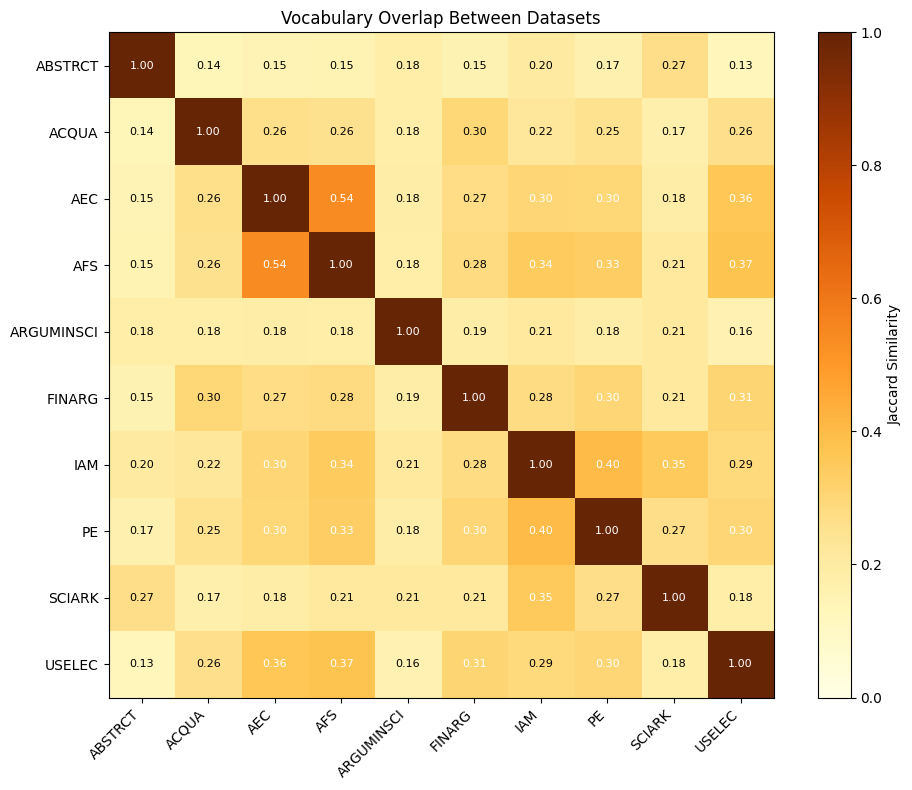

In [28]:
# Visualize overlap matrix
try:
    import matplotlib.pyplot as plt
    
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(overlap_matrix.values.astype(float), cmap='YlOrBr', vmin=0, vmax=1)
    
    ax.set_xticks(range(len(datasets)))
    ax.set_yticks(range(len(datasets)))
    ax.set_xticklabels(datasets, rotation=45, ha='right')
    ax.set_yticklabels(datasets)
    
    plt.colorbar(im, label='Jaccard Similarity')
    ax.set_title('Vocabulary Overlap Between Datasets')
    
    # Add text annotations
    for i in range(len(datasets)):
        for j in range(len(datasets)):
            val = overlap_matrix.iloc[i, j]
            ax.text(j, i, f'{val:.2f}', ha='center', va='center', 
                   color='white' if val > 0.3 else 'black', fontsize=8)
    
    plt.tight_layout()
    plt.show()
except ImportError:
    print("matplotlib not installed - skipping visualization")

## 7. Guideline Metadata Analysis

Exploring the annotation guidelines structure - key for the thesis approach of learning to apply guidelines.

In [17]:
# Unique guidelines per dataset
guideline_info = df.groupby('dataset')['guidelines'].first().reset_index()
guideline_info.columns = ['dataset', 'guidelines_path']

# Check if guideline files exist
guideline_info['file_exists'] = guideline_info['guidelines_path'].apply(
    lambda x: (GAIC_DATA_DIR / x.lstrip('./')).exists() if pd.notna(x) else False
)

print("Guideline files per dataset:")
print(guideline_info.to_string(index=False))

Guideline files per dataset:
   dataset                                   guidelines_path  file_exists
   ABSTRCT       ./ABSTRCT/guidelines/ABSTRCT-Guidelines.pdf         True
     ACQUA                                                 -        False
       AEC                                                 -        False
       AFS                                                 -        False
ARGUMINSCI ./ARGUMINSCI/guidelines/ARGUMINSCI-Guidelines.pdf         True
    FINARG                                                 -        False
       IAM                                                 -        False
        PE                 ./PE/guidelines/PE-Guidelines.pdf         True
    SCIARK                                                 -        False
    USELEC         ./USELEC/guidelines/USELEC-Guidelines.pdf         True


In [18]:
# List available guideline files
print("\nAvailable guideline files in GAIC data:")
for dataset_dir in sorted(GAIC_DATA_DIR.iterdir()):
    if dataset_dir.is_dir():
        guidelines_dir = dataset_dir / 'guidelines'
        if guidelines_dir.exists():
            files = list(guidelines_dir.iterdir())
            print(f"  {dataset_dir.name}/guidelines/: {[f.name for f in files]}")


Available guideline files in GAIC data:
  ABSTRCT/guidelines/: ['ABSTRCT-Guidelines.pdf']
  ARGUMINSCI/guidelines/: ['ARGUMINSCI-Guidelines.pdf']
  PE/guidelines/: ['PE-Guidelines.pdf']
  USELEC/guidelines/: ['USELEC-Guidelines.pdf']


In [19]:
# Paper references per dataset
paper_info = df.groupby('dataset')['paper'].first().reset_index()
paper_info.columns = ['dataset', 'paper_path']

print("\nDataset paper references:")
print(paper_info.to_string(index=False))


Dataset paper references:
   dataset                        paper_path
   ABSTRCT       ./ABSTRCT/paper/ABSTRCT.pdf
     ACQUA           ./ACQUA/paper/ACQUA.pdf
       AEC               ./AEC/paper/AEC.pdf
       AFS               ./AFS/paper/AFS.pdf
ARGUMINSCI ./ARGUMINSCI/paper/ARGUMINSCI.pdf
    FINARG         ./FINARG/paper/FINARG.pdf
       IAM               ./IAM/paper/IAM.pdf
        PE                 ./PE/paper/PE.pdf
    SCIARK         ./SCIARK/paper/SCIARK.pdf
    USELEC         ./USELEC/paper/USELEC.pdf


## 8. Summary Statistics & Key Findings

In [21]:
# Save key dataframes for future reference
output_dir = PROJECT_ROOT / 'experiments' / 'eda_outputs'
output_dir.mkdir(exist_ok=True)

class_balance.to_csv(output_dir / 'class_balance.csv')
length_stats.to_csv(output_dir / 'length_stats.csv')
overlap_matrix.to_csv(output_dir / 'vocab_overlap.csv')
marker_corr_df.to_csv(output_dir / 'marker_correlations.csv')

print(f"Saved analysis outputs to {output_dir}")

Saved analysis outputs to /Users/hanneswidera/Uni/Master/thesis/GAIC_thesis/experiments/../experiments/eda_outputs


DATASET OVERVIEW:
- Total samples: 13,600
- Number of datasets: 10
- Overall Argument ratio: 50.0%
CLASS IMBALANCE (potential for class-based shortcuts):
- Highest Argument ratio: ABSTRCT (50.0%)
- Lowest Argument ratio: ABSTRCT (50.0%)
SENTENCE LENGTH VARIATION:
- Datasets with longest sentences: SCIARK (mean 24.0 words)
    - Datasets with shortest sentences: USELEC (mean 16.4 words)
SHORTCUT RISK INDICATORS:
    - Discourse markers show varying correlation with Argument across datasets
    - Dataset-specific vocabulary exists (domain/topic shortcuts likely)
CROSS-DATASET TRANSFER POTENTIAL:
    - Most similar datasets: AEC & AFS (Jaccard: 0.537)
    - Most different datasets: ABSTRCT & SCIARK